# Use MACHO/Clump Orbits to Compute Stellar Heating

The most accurate answer for stellar heating is given by performing an N-body simulation for the stellar system. Most UFDs have a small stellar population of the order of a few hundred stars which makes an explicit N-body simulation feasible. Segue 1, for example, has a stellar mass of $570\, M_\odot$, corresponding to roughly $570$ stars.

We make the following assumptions:
1. Initially the stellar distribution is in equilibrium in the center of the galaxy, described by a Plummer density profile and a velocity dispersion which takes the DM background into account.
2. Star-Star interactions are negligible, i.e. the clumps only feel the potential generated by the DM host and the single clumps.

**A few words about conventions:**
I initially wrote the code to work with SatGen output, i.e. using cylindrical coordinates. If the clump/subhalo input is in Cartesian coordinates this has to be modified.

## Initialize Stellar Population and Dark Matter Background

As a first step we draw individual stars from the Plummer Profile and initialize the dark matter background (a simple cored Dehnen Profile).

In [12]:
from stellar_heating import Plummer, sigmastar_Plummer, init_plummer, NFW

# define seed for reproducibility
seed = 42
Nsteps = 500
tmax = 10.0  # [Gyr]
MMACHO= 1e4      # MACHO mass [M_sun]
fMACHO = 1e-3     # MACHO mass fraction

# NFW Host
host = NFW(M=1e9, c=11.6)
print("Host: Mvir = %.2e Msun, c = %.2f, z = %.2f, rs = %.2f" % (host.Mh, host.ch, host.z, host.rs))

# Stellar system initial conditions
Mstar_c = 5.7e2                          # total stellar mass [Msun]
r0i_c   = 0.2 * Mstar_c**(1./3.) / 1e3  # initial Plummer scale radius [kpc]

posStar_c, velStar_c = init_plummer(Mstar_c, r0i_c, host, m_star=1.0, seed=seed)

## CAUTION: NFW is in SatGen convention with cylindrical coordinates, but
##          init_plummer returns Cartesian coordinates.

Host: Mvir = 1.00e+09 Msun, c = 11.60, z = 0.00, rs = 1.78


### Compute simple trajectories for MACHOs/subhalos

This is for demonstrating the heating code. If the MACHO/clump trajectories are already available this step can be skipped. The output is in SatGen format, i.e. cylindrical coordinates and snapshots at 500 timesteps (SatGen has fewer timesteps)

**Note:**
There is no stripping, just pure orbit integration

In [13]:
import os
import sys
from pathlib import Path
from stellar_heating import initialize_subhalos
import numpy as np
import time
from tqdm import tqdm

posMACHO, velMACHO = initialize_subhalos(host, Msub=MMACHO, fc=fMACHO, seed=seed)

# 1. Locate the parent directory of the current file
parent_dir = str(Path(os.getcwd()).parent)


# 2. Add the parent directory to the Python path
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from orbit import orbit

def cartesion2cyl(posArray, velArray):
    x = posArray[:,0]
    y = posArray[:,1]
    z = posArray[:,2]
    
    vx = velArray[:,0]
    vy = velArray[:,1]
    vz = velArray[:,2]
    
    R = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    z_cyl = z
    
    vR = (x*vx + y*vy) / R
    vphi = (x*vy - y*vx) / R
    vz_cyl = vz
    
    return np.column_stack([R, phi, z_cyl, vR, vphi, vz_cyl])

def MACHO_Simulation(MMACHO, posMACHO, velMACHO, host, tmax, Nstep):
    NMACHO = len(posMACHO)
    xvList = np.zeros((NMACHO,Nstep+1,6))
    xvList[:,0,:] = cartesion2cyl(posMACHO, velMACHO)
    timesteps = np.linspace(0.,tmax,Nstep+1)[1::] #[Gyr]

    print('>>> evolving ... ')
    tprevious = 0.
    t1 = time.time()

    for i,t in tqdm(enumerate(timesteps)):
    
        dt = t -  tprevious

        for j in range(NMACHO):
            xv = xvList[j,i,:]
            o = orbit(xv) # initialize orbit with current position and velocity
            r = np.sqrt(xv[0]**2+xv[2]**2)

            #---evolve orbit
            o.integrate(dt,host,MMACHO)
            xv = o.xv
            # note that the coordinates are updated internally in the orbit 
            # instance "o", here we assign them to xv only for bookkeeping
            
            #---record
            xvList[j,i+1,:] = xv
        
        #---update tprevious
        tprevious = t

    t2 = time.time()
    print('    time = %.4f'%(t2-t1))

    return xvList, timesteps

In [14]:
xvMACHO, timesteps = MACHO_Simulation(MMACHO=MMACHO, posMACHO=posMACHO, velMACHO=velMACHO, host=host, tmax=tmax, Nstep=Nsteps)

>>> evolving ... 


500it [00:11, 42.69it/s] 

    time = 11.7156


## Stellar Heating assuming point-like MACHOs

As a first step and reference, we use point-like MACHOs to heat the stars.

In [15]:
from stellar_heating import stellar_simulation_clumps_pointmass_nb

mass_matrix = np.full((xvMACHO.shape[0], xvMACHO.shape[1]), MMACHO)

R0starL_M, HLRList_M, _, _, _ = stellar_simulation_clumps_pointmass_nb(
    xvMACHO, posStar_c, velStar_c, mass_matrix, host,
    timesteps, r0i_c, softening=1e-3, Nsteps=10000, earlyStop=False
)

  omega_max = 28.3 Gyr⁻¹   dt_outer = 1.0 Myr   n_substeps = 3   sub_dt = 0.33 Myr   total force evals/step = 9
>>> compiling numba kernels (first call may take a few seconds) ...
>>> evolving (Yoshida-4, numba-parallel, point-mass subhalos) ...


10000it [00:07, 1289.94it/s]


    time = 7.7539 s
r0i    = 0.0017 kpc
R0star = 0.0225 kpc  (x13.557)


## Stellar Heating assuming extended Clumps

Now we perform the same heating calculation with extended clumps. We assume a Dekel profile for the clumps (that's what SatGen uses internally)

In [19]:
Delta = 200.0
rs_clump    = 0.0005    # [kpc] = 0.5 pc  <<  rs_host = 1.78 kpc
alpha_clump = 0.5     # inner slope (mild cusp)
host_rhoc = host.rhoc # critical density at z=0 [Msun kpc^-3]
r_vir_clump = (3.0 * MMACHO / (4.0 * np.pi * Delta * host_rhoc)) ** (1.0 / 3.0)
c_clump     = r_vir_clump / rs_clump

N_sub, N_ts = xvMACHO.shape[0], xvMACHO.shape[1]
subhalo_M_arr     = np.full((N_sub, N_ts), MMACHO)
subhalo_c_arr     = np.full((N_sub, N_ts), c_clump)
subhalo_alpha_arr = np.full((N_sub, N_ts), alpha_clump)
subhalo_rh_arr    = np.full((N_sub, N_ts), r_vir_clump)

In [20]:
from stellar_heating import stellar_simulation_clumps_nb

R0starL_C, HLRList_C, _, _, _ = stellar_simulation_clumps_nb(
    xvMACHO, posStar_c, velStar_c,
    subhalo_M_arr, subhalo_c_arr, subhalo_alpha_arr, subhalo_rh_arr,
    host, timesteps, r0i_c, Nsteps=10000,
)

  omega_max = 28.3 Gyr⁻¹   dt_outer = 1.0 Myr   n_substeps = 3   sub_dt = 0.33 Myr   total force evals/step = 9
>>> compiling numba kernels (first call may take a few seconds) ...
>>> evolving (Yoshida-4, numba-parallel, Dekel subhalos) ...


10000it [00:42, 232.75it/s]


    time = 42.9665 s
r0i    = 0.0017 kpc
R0star = 0.0054 kpc  (x3.260)


## Comparison of the two

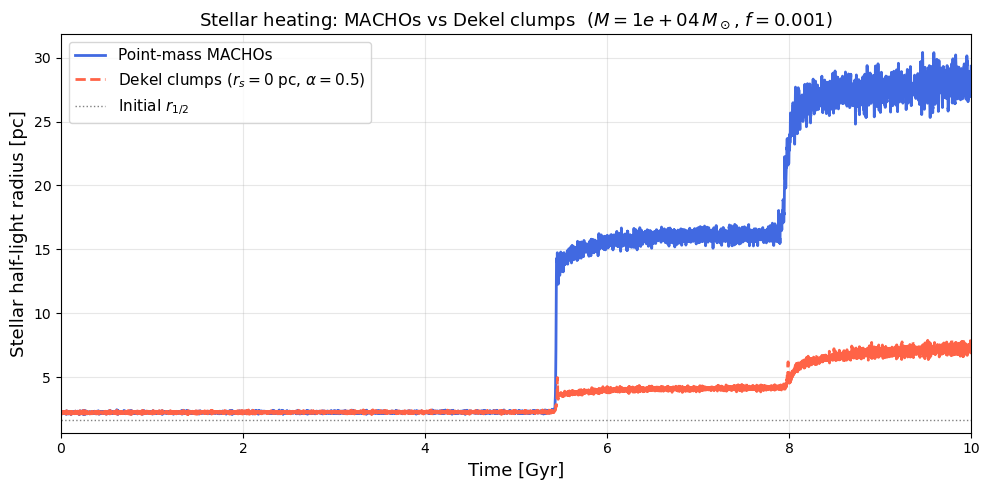

In [21]:
import matplotlib.pyplot as plt

t_plt = np.linspace(0, 10, 10001)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_plt, HLRList_M * 1e3, color='royalblue', lw=2,
        label='Point-mass MACHOs')
ax.plot(t_plt, HLRList_C * 1e3, color='tomato',    lw=2, ls='--',
        label=fr'Dekel clumps ($r_s={rs_clump*1e3:.0f}$ pc, $\alpha={alpha_clump}$)')
ax.axhline(r0i_c * 1e3, color='gray', ls=':', lw=1, label='Initial $r_{1/2}$')

ax.set_xlabel('Time [Gyr]', fontsize=13)
ax.set_ylabel('Stellar half-light radius [pc]', fontsize=13)
ax.set_title(
    fr'Stellar heating: MACHOs vs Dekel clumps  ($M={MMACHO:.0e}\,M_\odot$, $f={fMACHO}$)',
    fontsize=13,
)
ax.legend(fontsize=11)
ax.set_xlim(0, tmax)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()